First 5 Rows
    Order_ID Order_Date Customer_ID Customer_Name   Age  Gender       City  \
0  ORD100002 2025-02-25    CUST5529  Customer_227  30.0  Female  Bengaluru   
1  ORD100003 2025-10-14    CUST3127  Customer_182  63.0    Male  Bengaluru   
2  ORD100004 2025-05-13    CUST8887  Customer_487  62.0  Female  Bengaluru   
3  ORD100005 2025-12-02    CUST2515  Customer_470  65.0  Female    Kolkata   
4  ORD100006 2025-11-20    CUST4796  Customer_380  44.0    Male  Bengaluru   

  Product     Category  Quantity  Unit_Price  Total_Sales  
0    Rice      Grocery         7     2829.77     19808.39  
1    Book    Education         5    27906.16    139530.80  
2    Book    Education         8    37491.06    299928.48  
3  Mobile  Electronics         9    28541.36    256872.24  
4    Rice      Grocery        10    14036.59    140365.90  

Missing Values
Order_ID          0
Order_Date        0
Customer_ID       0
Customer_Name     0
Age              20
Gender            0
City             13
Pr

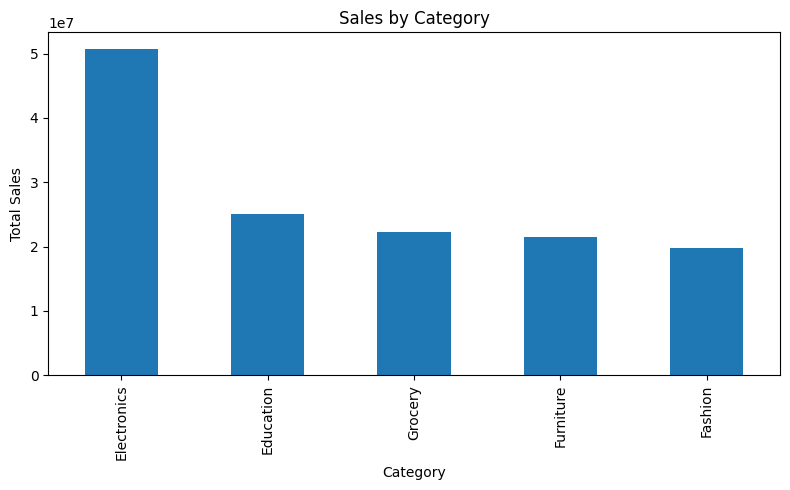

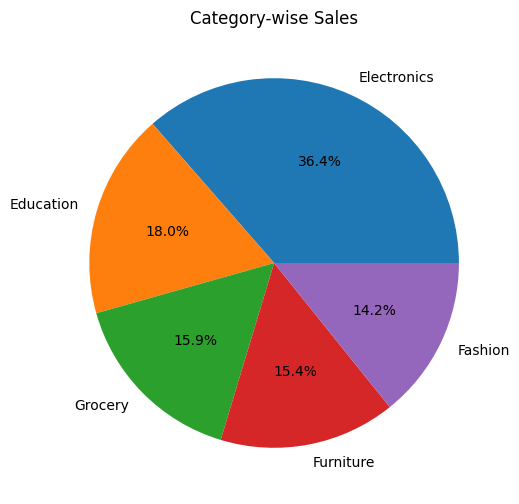

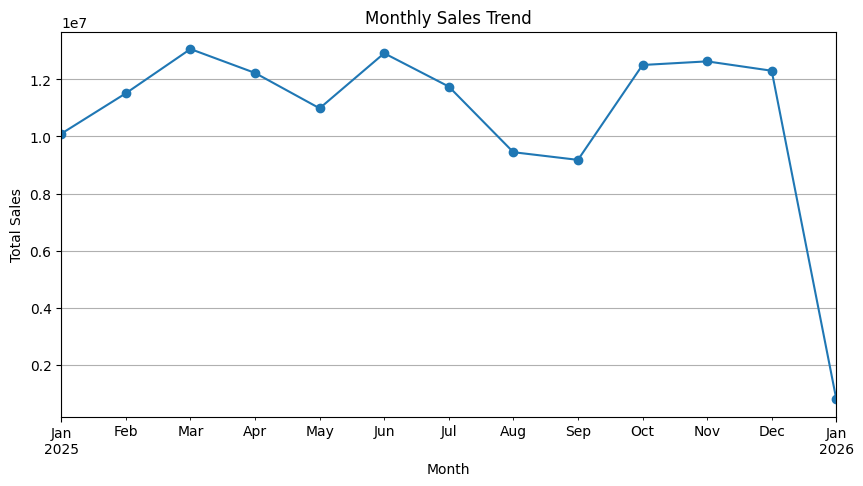

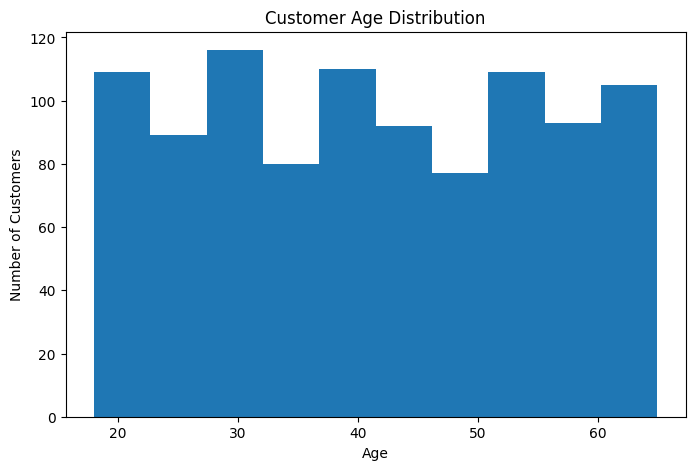

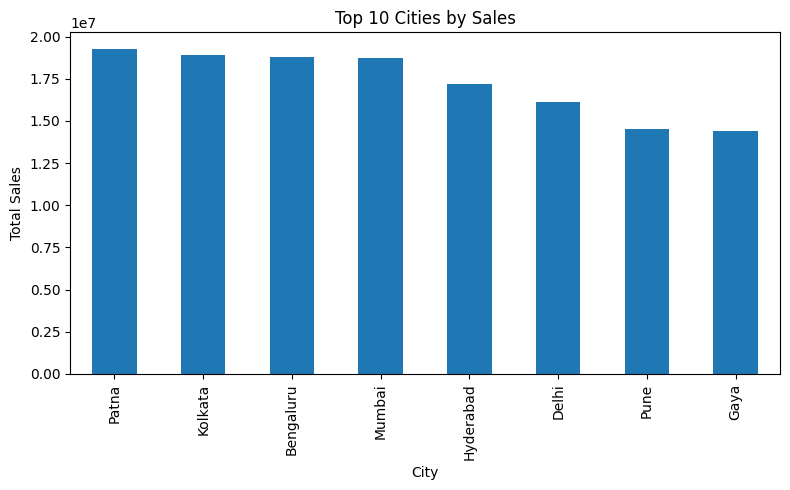

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_excel('/content/ApexPlanet_DataAnalytics_Dataset.xlsx')

# Convert Order Date
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# ============================
# DATA OVERVIEW
# ============================

print("First 5 Rows")
print(df.head())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

# ============================
# KPI ANALYSIS
# ============================

total_sales = df['Total_Sales'].sum()
total_orders = df['Order_ID'].nunique()
average_order_value = total_sales / total_orders
average_age = df['Age'].mean()

print("\n========== KPI REPORT ==========")
print("Total Sales:", round(total_sales,2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value,2))
print("Average Customer Age:", round(average_age,2))

# ============================
# TOP CATEGORY
# ============================

category_sales = df.groupby('Category')['Total_Sales'].sum().sort_values(ascending=False)

print("\nSales by Category")
print(category_sales)

# ============================
# TOP CITY
# ============================

city_sales = df.groupby('City')['Total_Sales'].sum().sort_values(ascending=False)

print("\nSales by City")
print(city_sales)

# ============================
# TOP PRODUCTS
# ============================

product_sales = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)

print("\nTop 10 Products")
print(product_sales.head(10))

# ============================
# MONTHLY SALES TREND
# ============================

monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Total_Sales'].sum()

print("\nMonthly Sales")
print(monthly_sales)

# ============================
# BAR CHART
# ============================

category_sales.plot(kind='bar', figsize=(8,5))
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

# ============================
# PIE CHART
# ============================

category_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Category-wise Sales")
plt.ylabel("")
plt.show()

# ============================
# LINE CHART
# ============================

monthly_sales.plot(figsize=(10,5), marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

# ============================
# HISTOGRAM
# ============================

plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=10)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

# ============================
# TOP 10 CITIES
# ============================

city_sales.head(10).plot(kind='bar', figsize=(8,5))
plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()